# Results analysis

This notebook loads the two main experiment results and the 30-seed reproduction results, then reports descriptive statistics and creates plots for return, discounted return, query use, and data delivery.

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:.3f}".format)

# The CSV files are stored next to this notebook.
results_dir = Path.cwd()
if not (results_dir / "main_L.csv").exists():
    results_dir = Path.cwd().parent / "results"

file_paths = {
    "main_L": results_dir / "main_L.csv",
    "main_M": results_dir / "main_M.csv",
    "reproduction_30seeds": results_dir / "reproduction_30seeds.csv",
}

results = {name: pd.read_csv(path) for name, path in file_paths.items()}
for name, frame in results.items():
    print(f"{name}: {frame.shape[0]:,} rows x {frame.shape[1]} columns")
    display(frame.head())

main_L: 720 rows x 20 columns


,env,rho,dataset,n_traj,seed,agent,optimal_ret,data_pct_delivered,n_SD,n_inconsistent,n_eval_starts,ret,disc_ret,queries_per_ep,pct_ep_with_query,frac_data_steps,frac_model_steps,frac_query_steps,pct_delivered,config_seconds
0,taxi-L,0.000,drivers,150,0,Imitation,-19.292,100.000,3397,0,1000,-39.560,-33.557,8.945,91.000,0.820,0.000,0.180,100.000,55.777
1,taxi-L,0.000,drivers,150,0,BC,-19.292,100.000,3397,0,1000,-313.318,-132.880,8.945,91.000,0.905,0.000,0.095,67.100,55.777
2,taxi-L,0.000,drivers,150,0,RECO,-19.292,100.000,3397,0,1000,-44.321,-36.795,0.838,10.700,0.864,0.120,0.016,100.000,55.777
3,taxi-L,0.000,drivers,150,0,RECO-greedy,-19.292,100.000,3397,0,1000,-24.096,-22.259,0.838,10.700,0.840,0.141,0.019,100.000,55.777
4,taxi-L,0.000,drivers,150,0,In-data planning (POR-style),-19.292,100.000,3397,0,1000,-21.384,-20.236,8.945,91.000,0.789,0.000,0.211,100.000,55.777


main_M: 4,860 rows x 19 columns


,env,rho,dataset,n_traj,seed,agent,optimal_ret,data_pct_delivered,n_SD,n_inconsistent,ret,disc_ret,queries_per_ep,pct_ep_with_query,frac_data_steps,frac_model_steps,frac_query_steps,pct_delivered,config_seconds
0,taxi-M,0.000,drivers,50,0,Imitation,-3.553,100.000,487,0,-13.128,-13.518,3.308,75.750,0.882,0.000,0.118,100.000,29.013
1,taxi-M,0.000,drivers,50,0,BC,-3.553,100.000,487,0,-66.539,-31.632,3.308,75.750,0.898,0.000,0.102,95.583,29.013
2,taxi-M,0.000,drivers,50,0,RECO,-3.553,100.000,487,0,-15.101,-15.200,0.040,4.000,0.881,0.118,0.001,100.000,29.013
3,taxi-M,0.000,drivers,50,0,RECO-greedy,-3.553,100.000,487,0,-5.358,-6.814,0.040,4.000,0.865,0.133,0.002,100.000,29.013
4,taxi-M,0.000,drivers,50,0,In-data planning (POR-style),-3.553,100.000,487,0,-3.730,-5.330,3.308,75.750,0.866,0.000,0.134,100.000,29.013


reproduction_30seeds: 600 rows x 20 columns


,env,rho,dataset,n_traj,seed,agent,optimal_ret,data_pct_delivered,n_SD,n_inconsistent,n_eval_starts,ret,disc_ret,queries_per_ep,pct_ep_with_query,frac_data_steps,frac_model_steps,frac_query_steps,pct_delivered,config_seconds
0,taxi-v3,0.000,expert,10,0,Imitation,7.930,100.000,90,0,300,7.930,6.327,4.720,84.333,0.639,0.000,0.361,100.000,0.965
1,taxi-v3,0.000,expert,10,0,RECO,7.930,100.000,90,0,300,7.417,5.784,2.543,51.000,0.663,0.150,0.187,100.000,0.965
2,taxi-v3,0.000,expert,10,0,Ours,7.930,100.000,90,0,300,7.517,5.888,2.543,51.000,0.657,0.155,0.189,100.000,0.965
3,taxi-v3,0.000,expert,10,0,Factored Batch RL,7.930,100.000,90,0,300,7.283,5.641,0.240,16.000,0.645,0.337,0.017,100.000,0.965
4,taxi-v3,0.000,expert,10,1,Imitation,7.930,100.000,69,0,300,7.930,6.327,6.527,88.667,0.501,0.000,0.499,100.000,0.699


## Data overview and quality checks

In [4]:
for name, frame in results.items():
    print(f"\n{name}")
    print("Environments:", sorted(frame["env"].dropna().unique()))
    print("Datasets:", sorted(frame["dataset"].dropna().unique()))
    print("Agents:", sorted(frame["agent"].dropna().unique()))
    print("Seeds:", frame["seed"].nunique())
    print("Missing values:", int(frame.isna().sum().sum()))
    print("Duplicate rows:", int(frame.duplicated().sum()))
    display(frame.describe(include="all").T)


main_L
Environments: ['taxi-L']
Datasets: ['drivers', 'random_mix']
Agents: ['BC', 'Factored Batch RL', 'Imitation', 'In-data planning (POR-style)', 'Ours', 'Ours w/o execution rule', 'Ours w/o stitching', 'RECO', 'RECO-greedy']
Seeds: 10
Missing values: 0
Duplicate rows: 0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
env,720,1,taxi-L,720,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rho,720.000,NaN,NaN,NaN,0.250,0.250,0.000,0.000,0.250,0.500,0.500
dataset,720,2,drivers,360,NaN,NaN,NaN,NaN,NaN,NaN,NaN
n_traj,720.000,NaN,NaN,NaN,275.000,125.087,150.000,150.000,275.000,400.000,400.000
seed,720.000,NaN,NaN,NaN,4.500,2.874,0.000,2.000,4.500,7.000,9.000
agent,720,9,Imitation,80,NaN,NaN,NaN,NaN,NaN,NaN,NaN
optimal_ret,720.000,NaN,NaN,NaN,-26.779,13.780,-59.734,-24.312,-20.119,-19.292,-19.292
data_pct_delivered,720.000,NaN,NaN,NaN,67.682,29.075,28.667,40.250,56.000,100.000,100.000
n_SD,720.000,NaN,NaN,NaN,5915.462,2525.893,2507.000,4367.500,4987.500,7643.750,10576.000
n_inconsistent,720.000,NaN,NaN,NaN,4.900,6.974,0.000,0.000,0.500,9.000,22.000



main_M
Environments: ['taxi-M']
Datasets: ['drivers', 'noisy_expert', 'random_mix']
Agents: ['BC', 'Factored Batch RL', 'Imitation', 'In-data planning (POR-style)', 'Ours', 'Ours w/o execution rule', 'Ours w/o stitching', 'RECO', 'RECO-greedy']
Seeds: 30
Missing values: 0
Duplicate rows: 0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
env,4860,1,taxi-M,4860,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rho,4860.000,NaN,NaN,NaN,0.250,0.204,0.000,0.000,0.250,0.500,0.500
dataset,4860,3,drivers,1620,NaN,NaN,NaN,NaN,NaN,NaN,NaN
n_traj,4860.000,NaN,NaN,NaN,100.000,50.005,50.000,50.000,100.000,150.000,150.000
seed,4860.000,NaN,NaN,NaN,14.500,8.656,0.000,7.000,14.500,22.000,29.000
agent,4860,9,Imitation,540,NaN,NaN,NaN,NaN,NaN,NaN,NaN
optimal_ret,4860.000,NaN,NaN,NaN,-6.781,14.610,-100.517,-4.633,-3.823,-3.553,-3.553
data_pct_delivered,4860.000,NaN,NaN,NaN,79.175,28.448,21.333,44.000,100.000,100.000,100.000
n_SD,4860.000,NaN,NaN,NaN,773.165,302.401,336.000,493.000,730.000,889.750,1429.000
n_inconsistent,4860.000,NaN,NaN,NaN,1.109,1.929,0.000,0.000,0.000,2.000,8.000



reproduction_30seeds
Environments: ['taxi-v3']
Datasets: ['expert']
Agents: ['Factored Batch RL', 'Imitation', 'Ours', 'RECO']
Seeds: 30
Missing values: 0
Duplicate rows: 0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
env,600,1,taxi-v3,600,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rho,600.000,NaN,NaN,NaN,0.000,0.000,0.000,0.000,0.000,0.000,0.000
dataset,600,1,expert,600,NaN,NaN,NaN,NaN,NaN,NaN,NaN
n_traj,600.000,NaN,NaN,NaN,70.000,50.241,10.000,30.000,60.000,100.000,150.000
seed,600.000,NaN,NaN,NaN,14.500,8.663,0.000,7.000,14.500,22.000,29.000
agent,600,4,Imitation,150,NaN,NaN,NaN,NaN,NaN,NaN,NaN
optimal_ret,600.000,NaN,NaN,NaN,7.930,0.000,7.930,7.930,7.930,7.930,7.930
data_pct_delivered,600.000,NaN,NaN,NaN,100.000,0.000,100.000,100.000,100.000,100.000,100.000
n_SD,600.000,NaN,NaN,NaN,185.053,61.267,67.000,147.000,191.500,236.000,286.000
n_inconsistent,600.000,NaN,NaN,NaN,0.000,0.000,0.000,0.000,0.000,0.000,0.000


## Agent-level summary statistics

The tables below aggregate over seeds and other experimental dimensions. The standard deviation measures variation between recorded runs.

In [5]:
summary_metrics = [
    "ret",
    "disc_ret",
    "queries_per_ep",
    "pct_ep_with_query",
    "pct_delivered",
    "config_seconds",
]

agent_summaries = {}
for name, frame in results.items():
    summary = (
        frame.groupby("agent")[summary_metrics]
        .agg(["count", "mean", "std", "min", "max"])
        .round(3)
    )
    agent_summaries[name] = summary
    print(f"\n{name}")
    display(summary)

combined = pd.concat(
    [frame.assign(experiment=name) for name, frame in results.items()],
    ignore_index=True,
)
display(
    combined.groupby(["experiment", "agent"])[["ret", "disc_ret", "queries_per_ep", "pct_delivered"]]
    .agg(["mean", "std"])
    .round(3)
)


main_L


ret                                     \
                             count     mean     std       min     max   
agent                                                                   
BC                              80 -514.206 300.295 -1102.061 -80.402   
Factored Batch RL               80  -32.295  28.351  -132.362 -18.315   
Imitation                       80 -220.886 183.718  -502.473 -35.857   
In-data planning (POR-style)    80 -189.348 166.632  -444.017 -18.857   
Ours                            80  -90.865  86.503  -295.608 -18.549   
Ours w/o execution rule         80 -109.603  82.495  -295.608 -18.549   
Ours w/o stitching              80 -130.501 112.639  -351.791 -18.965   
RECO                            80 -277.462 230.241  -588.897 -39.626   
RECO-greedy                     80 -277.437 259.886  -740.822 -20.968   

                             disc_ret                                    \
                                count     mean     std      min     max   
agent                                                                     
BC                                 80 -220.787 125.421 -467.569 -45.466   
Factored Batch RL                  80  -24.459  11.342  -64.709 -17.820   
Imitation                          80 -107.878  76.333 -229.090 -31.139   
In-data planning (POR-style)       80  -89.483  68.690 -195.745 -18.255   
Ours                               80  -48.451  34.624 -128.682 -18.011   
Ours w/o execution rule            80  -54.518  33.244 -128.682 -18.011   
Ours w/o stitching                 80  -64.775  45.322 -152.375 -18.350   
RECO                               80 -131.459  94.201 -263.395 -33.938   
RECO-greedy                        80 -126.103 106.325 -316.041 -19.921   

                             queries_per_ep                             \
                                      count   mean    std   min    max   
agent                                                                    
BC                                       80 11.833 11.588 3.367 47.142   
Factored Batch RL                        80  2.231  5.715 0.000 24.200   
Imitation                                80 12.163 11.581 3.509 47.413   
In-data planning (POR-style)             80 11.833 11.588 3.367 47.142   
Ours                                     80  2.647  5.423 0.000 24.330   
Ours w/o execution rule                  80  1.914  4.477 0.000 24.330   
Ours w/o stitching                       80  2.644  5.454 0.000 24.330   
RECO                                     80  2.624  5.409 0.000 24.330   
RECO-greedy                              80  2.624  5.409 0.000 24.330   

                             pct_ep_with_query                              \
                                         count   mean    std    min    max   
agent                                                                        
BC                                          80 78.389 11.587 56.200 93.600   
Factored Batch RL                           80  6.509  9.731  0.000 43.500   
Imitation                                   80 79.276 10.802 58.400 93.600   
In-data planning (POR-style)                80 78.389 11.587 56.200 93.600   
Ours                                        80  8.009  9.913  0.000 53.400   
Ours w/o execution rule                     80  5.891  5.460  0.000 18.200   
Ours w/o stitching                          80  7.369  8.312  0.000 38.800   
RECO                                        80  7.075  7.504  0.000 36.500   
RECO-greedy                                 80  7.075  7.504  0.000 36.500   

                             pct_delivered                               \
                                     count   mean    std    min     max   
agent                                                                     
BC                                      80 56.985 19.661 22.800  92.600   
Factored Batch RL                       80 96.679  7.965 76.700 100.000   
Imitation                               80 76.439 21


main_M


ret                                     \
                             count     mean     std       min     max   
agent                                                                   
BC                             540 -440.024 476.778 -1366.912 -16.103   
Factored Batch RL              540  -11.158  35.964  -332.934  -3.553   
Imitation                      540 -187.147 243.128  -706.189 -10.591   
In-data planning (POR-style)   540  -58.357 125.960  -722.369  -3.553   
Ours                           540  -25.303  57.032  -352.632  -3.553   
Ours w/o execution rule        540  -44.555  57.577  -352.632  -3.553   
Ours w/o stitching             540  -38.539  78.951  -452.443  -3.577   
RECO                           540 -195.161 251.759  -698.694 -12.409   
RECO-greedy                    540  -68.250 146.558  -770.622  -3.770   

                             disc_ret                                    \
                                count     mean     std      min     max   
agent                                                                     
BC                                540 -190.926 203.389 -587.132 -10.650   
Factored Batch RL                 540   -8.865  15.329 -144.002  -5.165   
Imitation                         540  -92.764 110.133 -310.553 -11.362   
In-data planning (POR-style)      540  -28.874  53.668 -312.060  -5.165   
Ours                              540  -15.028  24.089 -154.819  -5.165   
Ours w/o execution rule           540  -22.445  24.323 -154.819  -5.165   
Ours w/o stitching                540  -20.629  33.507 -196.057  -5.187   
RECO                              540  -96.579 113.360 -308.318 -12.972   
RECO-greedy                       540  -33.416  62.254 -330.664  -5.370   

                             queries_per_ep                           \
                                      count  mean   std   min    max   
agent                                                                  
BC                                      540 2.992 6.036 0.033 57.055   
Factored Batch RL                       540 0.697 4.008 0.000 41.667   
Imitation                               540 3.060 6.031 0.033 57.055   
In-data planning (POR-style)            540 2.990 6.037 0.033 57.055   
Ours                                    540 0.572 3.608 0.000 41.667   
Ours w/o execution rule                 540 0.285 2.191 0.000 41.667   
Ours w/o stitching                      540 0.572 3.608 0.000 41.667   
RECO                                    540 0.572 3.611 0.000 41.667   
RECO-greedy                             540 0.572 3.611 0.000 41.667   

                             pct_ep_with_query                             \
                                         count   mean    std   min    max   
agent                                                                       
BC                                         540 51.072 23.638 2.750 81.250   
Factored Batch RL                          540  6.621 11.068 0.000 56.500   
Imitation                                  540 51.556 23.219 2.750 81.250   
In-data planning (POR-style)               540 51.068 23.641 2.750 81.250   
Ours                                       540  2.262  4.644 0.000 34.000   
Ours w/o execution rule                    540  1.935  3.689 0.000 23.000   
Ours w/o stitching                         540  2.242  4.555 0.000 34.000   
RECO                                       540  2.225  4.495 0.000 34.000   
RECO-greedy                                540  2.225  4.495 0.000 34.000   

                             pct_delivered                               \
                                     count   mean    std    min     max   
agent                                                                     
BC                                     540 64.310 35.126  2.667  99.500   
Factored Batch RL                      540 98.387  7.990 50.000 100.000   
Imitation                              540 81.397 25.513 20.361 100.000   
In-data plann


reproduction_30seeds


ret                         disc_ret                    \
                  count  mean   std   min   max    count  mean   std   min   
agent                                                                        
Factored Batch RL   150 7.797 0.205 7.057 7.930      150 6.187 0.217 5.397   
Imitation           150 7.930 0.000 7.930 7.930      150 6.327 0.000 6.327   
Ours                150 7.826 0.154 7.237 7.930      150 6.218 0.164 5.588   
RECO                150 7.743 0.167 7.150 7.923      150 6.130 0.177 5.496   

                        queries_per_ep                          \
                    max          count  mean   std   min   max   
agent                                                            
Factored Batch RL 6.327            150 0.189 0.756 0.000 5.197   
Imitation         6.327            150 1.886 1.729 0.393 7.010   
Ours              6.327            150 0.671 1.207 0.000 5.617   
RECO              6.321            150 0.671 1.207 0.000 5.617   

                  pct_ep_with_query                             pct_delivered  \
                              count   mean    std    min    max         count   
agent                                                                           
Factored Batch RL               150  4.164 10.041  0.000 62.667           150   
Imitation                       150 56.367 18.650 24.000 89.000           150   
Ours                            150 12.149 19.976  0.000 68.333           150   
RECO                            150 12.149 19.976  0.000 68.333           150   

                                                config_seconds              \
                     mean   std     min     max          count  mean   std   
agent                                                                        
Factored Batch RL 100.000 0.000 100.000 100.000            150 1.591 0.475   
Imitation         100.000 0.000 100.000 100.000            150 1.591 0.475   
Ours              100.000 0.000 100.000 100.000            150 1.591 0.475   
RECO              100.000 0.000 100.000 100.000            150 1.591 0.475   

                               
                    min   max  
agent                          
Factored Batch RL 0.699 2.356  
Imitation         0.699 2.356  
Ours              0.699 2.356  
RECO              0.699 2.356

ret         disc_ret  \
                                                      mean     std     mean   
experiment           agent                                                    
main_L               BC                           -514.206 300.295 -220.787   
                     Factored Batch RL             -32.295  28.351  -24.459   
                     Imitation                    -220.886 183.718 -107.878   
                     In-data planning (POR-style) -189.348 166.632  -89.483   
                     Ours                          -90.865  86.503  -48.451   
                     Ours w/o execution rule      -109.603  82.495  -54.518   
                     Ours w/o stitching           -130.501 112.639  -64.775   
                     RECO                         -277.462 230.241 -131.459   
                     RECO-greedy                  -277.437 259.886 -126.103   
main_M               BC                           -440.024 476.778 -190.926   
                     Factored Batch RL             -11.158  35.964   -8.865   
                     Imitation                    -187.147 243.128  -92.764   
                     In-data planning (POR-style)  -58.357 125.960  -28.874   
                     Ours                          -25.303  57.032  -15.028   
                     Ours w/o execution rule       -44.555  57.577  -22.445   
                     Ours w/o stitching            -38.539  78.951  -20.629   
                     RECO                         -195.161 251.759  -96.579   
                     RECO-greedy                   -68.250 146.558  -33.416   
reproduction_30seeds Factored Batch RL               7.797   0.205    6.187   
                     Imitation                       7.930   0.000    6.327   
                     Ours                            7.826   0.154    6.218   
                     RECO                            7.743   0.167    6.130   

                                                          queries_per_ep  \
                                                      std           mean   
experiment           agent                                                 
main_L               BC                           125.421         11.833   
                     Factored Batch RL             11.342          2.231   
                     Imitation                     76.333         12.163   
                     In-data planning (POR-style)  68.690         11.833   
                     Ours                          34.624          2.647   
                     Ours w/o execution rule       33.244          1.914   
                     Ours w/o stitching            45.322          2.644   
                     RECO                          94.201          2.624   
                     RECO-greedy                  106.325          2.624   
main_M               BC                           203.389          2.992   
                     Factored Batch RL             15.329          0.697   
                     Imitation                    110.133          3.060   
                     In-data planning (POR-style)  53.668          2.990   
                     Ours                          24.089          0.572   
                     Ours w/o execution rule       24.323          0.285   
                     Ours w/o stitching            33.507          0.572   
                     RECO                         113.360          0.572   
                     RECO-greedy                   62.254          0.572   
reproduction_30seeds Factored Batch RL              0.217          0.189   
                     Imitation                      0.000          1.886   
                     Ours                           0.164          0.671   
                     RECO                           0.177          0.671   

                                                         pct_delivered         
                                                     std          mean    std  
experiment        

## Plots

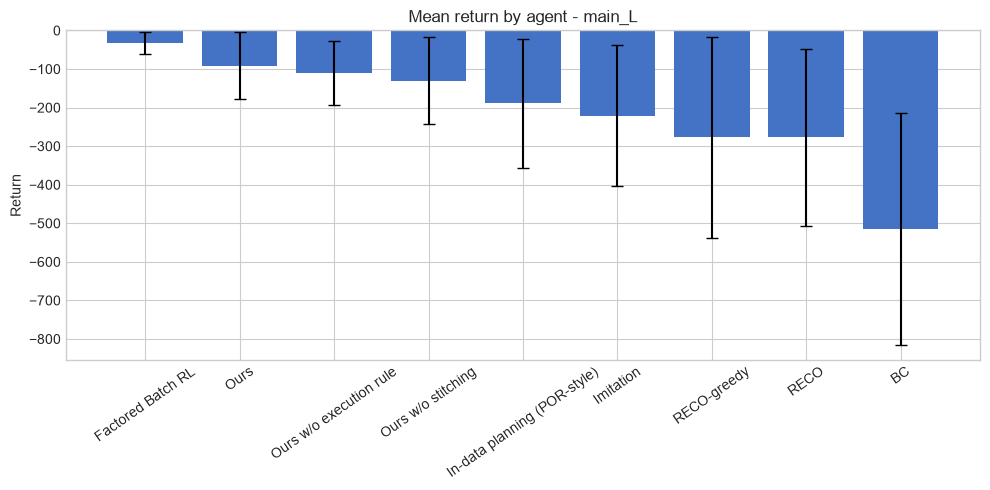

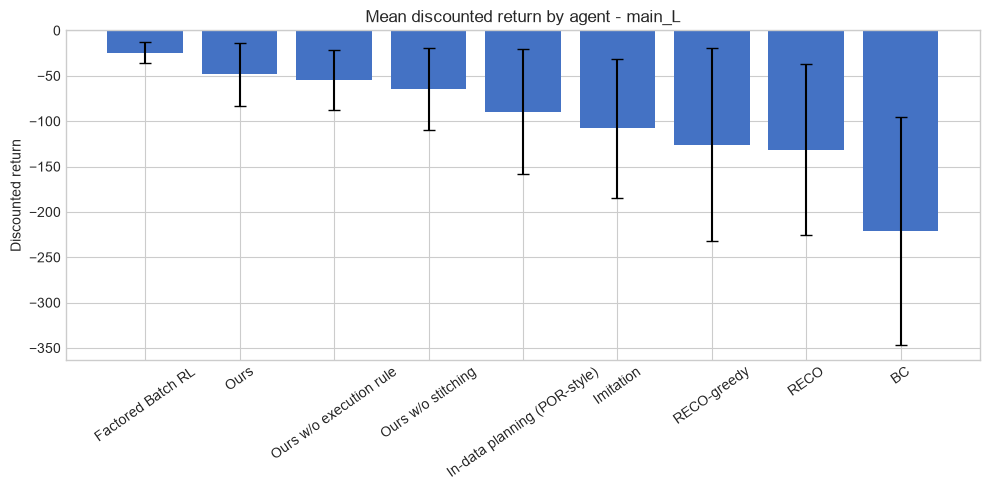

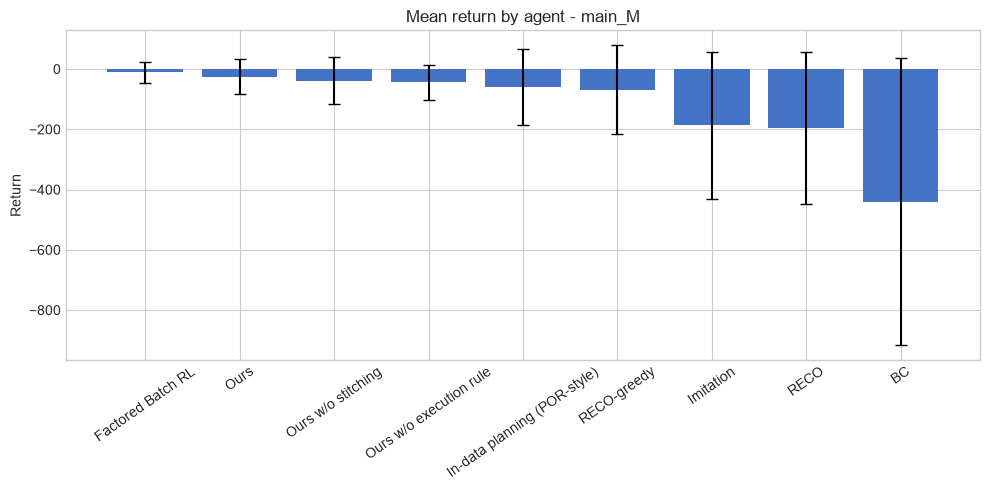

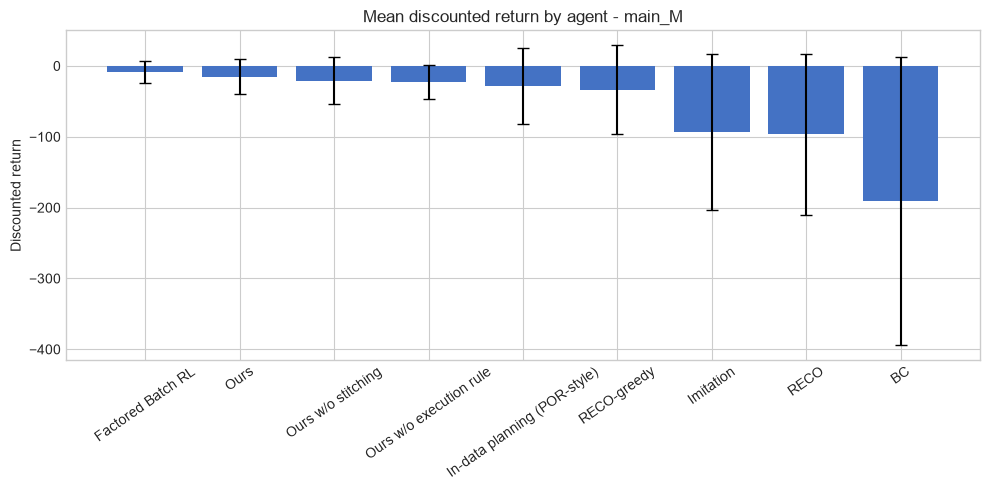

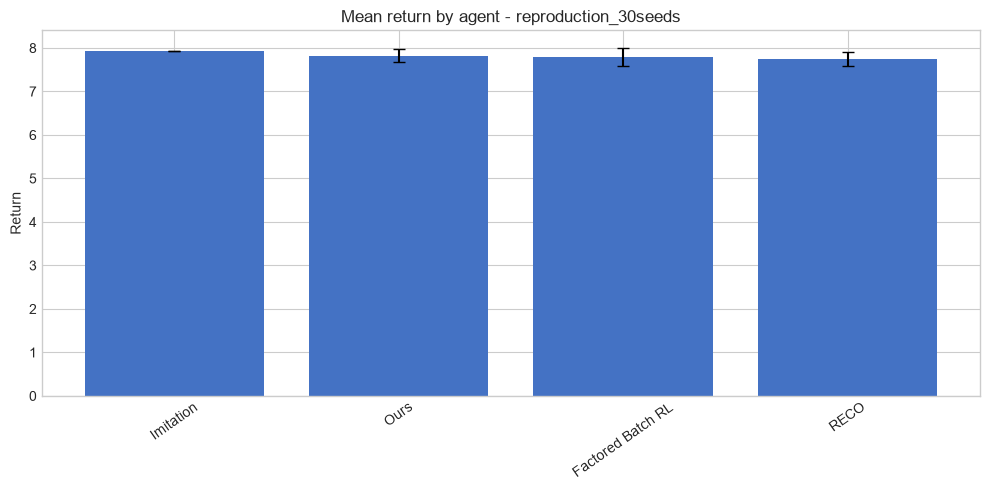

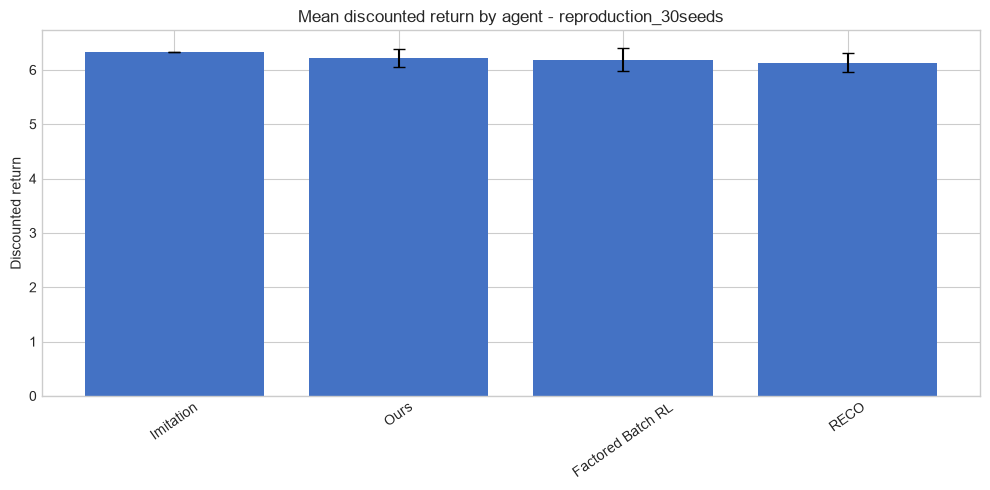

In [6]:
def plot_metric_by_agent(frame, metric, title, ylabel):
    means = frame.groupby("agent")[metric].mean().sort_values(ascending=False)
    errors = frame.groupby("agent")[metric].std().reindex(means.index).fillna(0)
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(means.index, means.values, yerr=errors.values, capsize=4, color="#4472C4")
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=35)
    fig.tight_layout()
    plt.show()

for name, frame in results.items():
    plot_metric_by_agent(frame, "ret", f"Mean return by agent - {name}", "Return")
    plot_metric_by_agent(frame, "disc_ret", f"Mean discounted return by agent - {name}", "Discounted return")

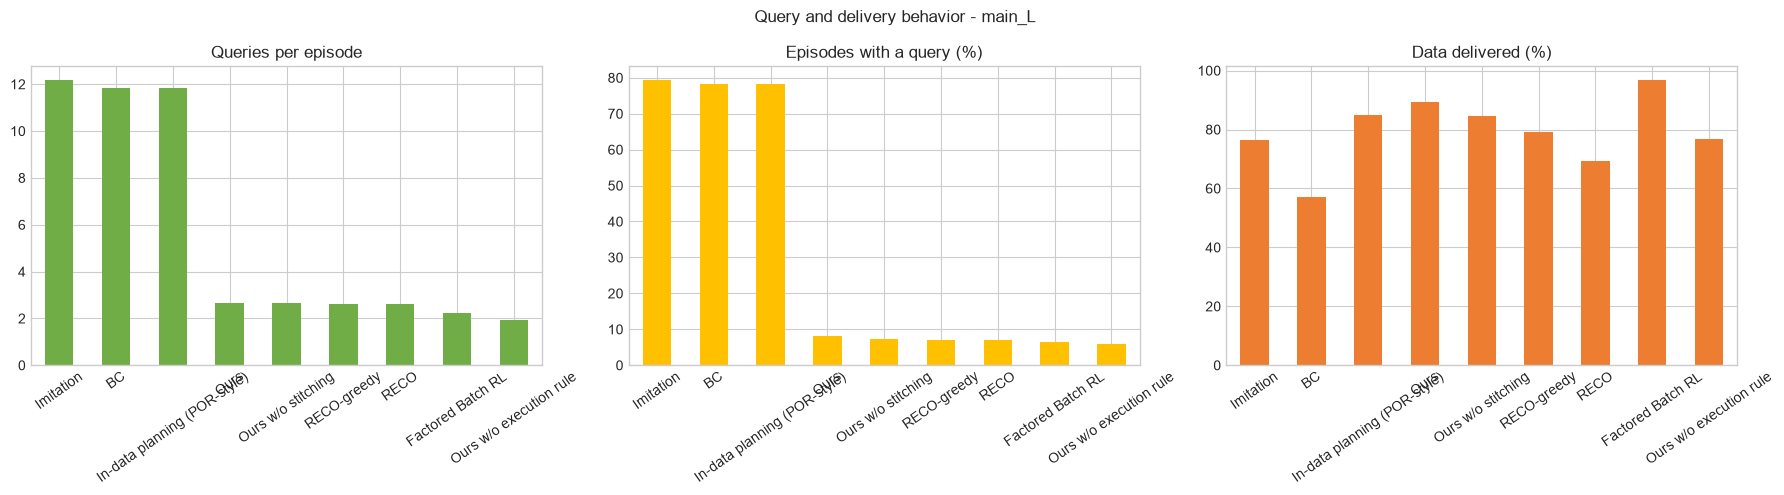

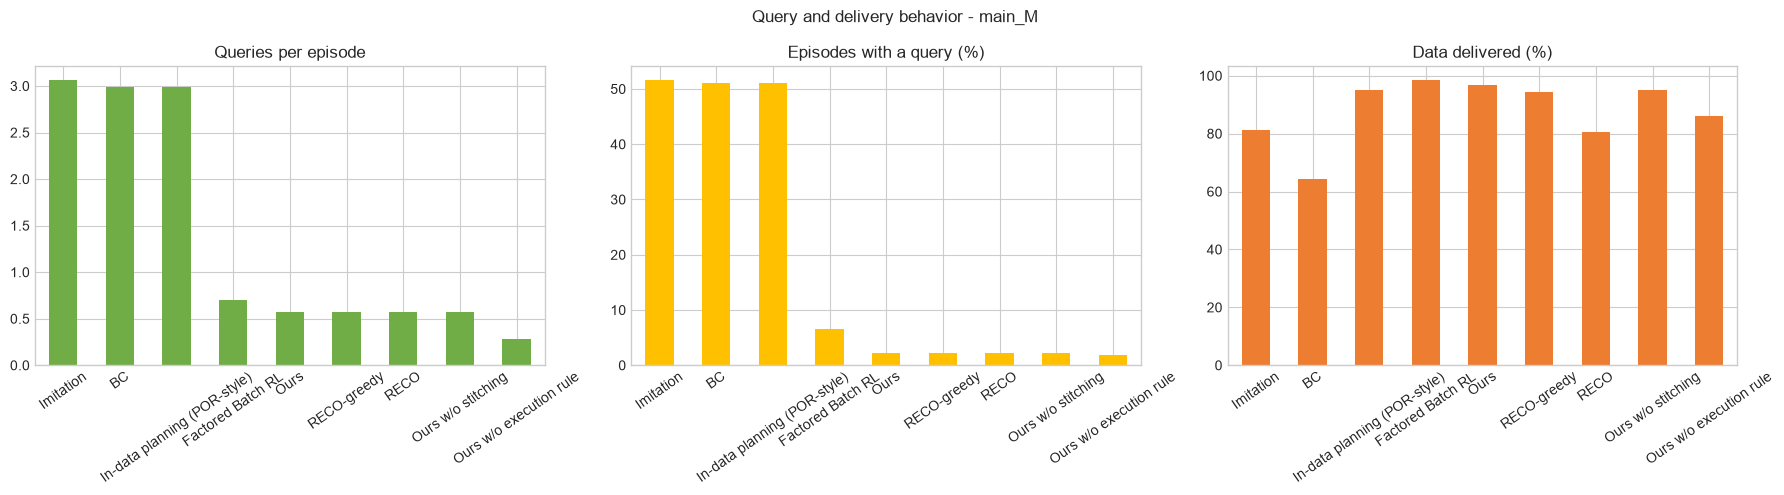

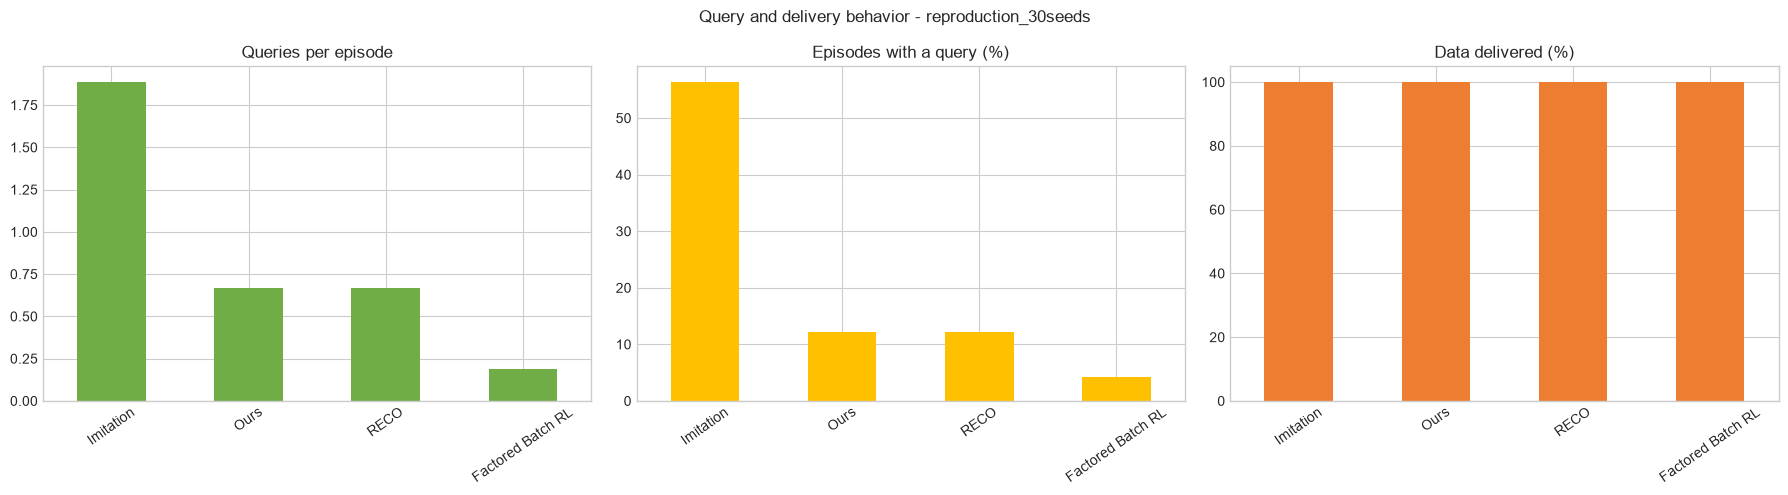

In [7]:
for name, frame in results.items():
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    means = frame.groupby("agent")[["queries_per_ep", "pct_ep_with_query", "pct_delivered"]].mean()
    means = means.sort_values("queries_per_ep", ascending=False)
    means["queries_per_ep"].plot.bar(ax=axes[0], color="#70AD47", title="Queries per episode")
    means["pct_ep_with_query"].plot.bar(ax=axes[1], color="#FFC000", title="Episodes with a query (%)")
    means["pct_delivered"].plot.bar(ax=axes[2], color="#ED7D31", title="Data delivered (%)")
    for axis in axes:
        axis.set_xlabel("")
        axis.tick_params(axis="x", rotation=35)
    fig.suptitle(f"Query and delivery behavior - {name}")
    fig.tight_layout()
    plt.show()

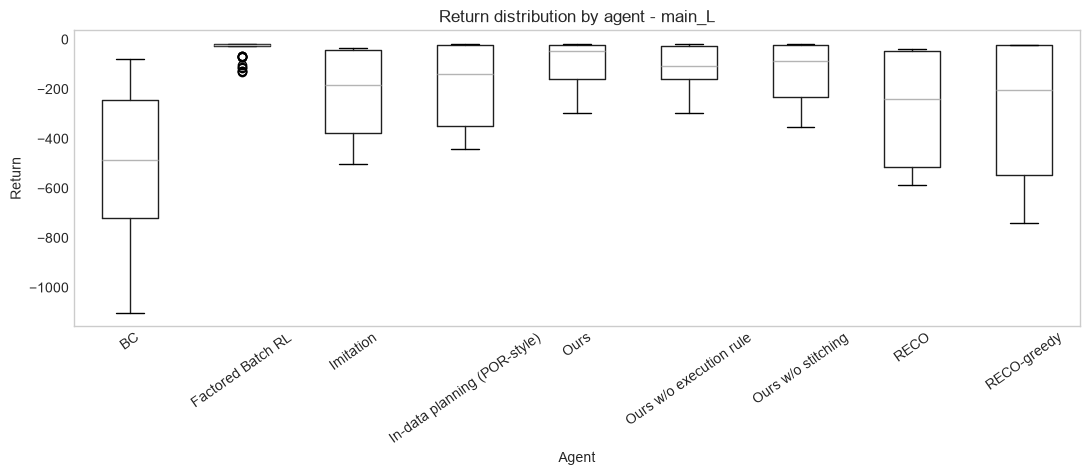

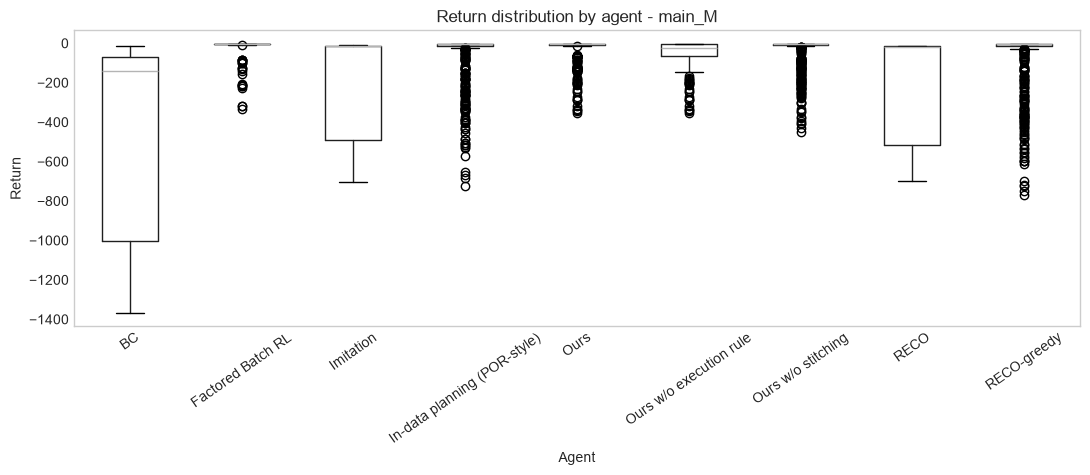

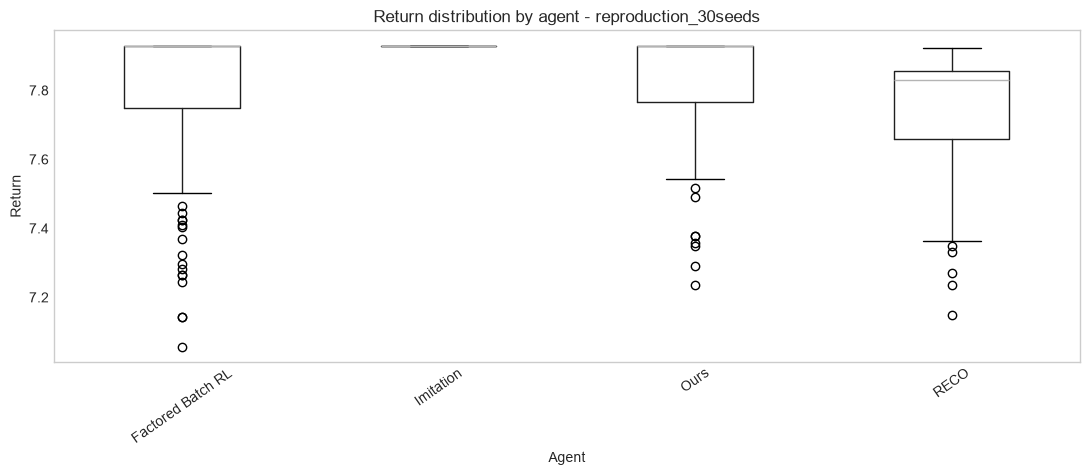

In [8]:
for name, frame in results.items():
    fig, ax = plt.subplots(figsize=(11, 5))
    frame.boxplot(column="ret", by="agent", ax=ax, grid=False)
    ax.set_title(f"Return distribution by agent - {name}")
    ax.set_xlabel("Agent")
    ax.set_ylabel("Return")
    plt.suptitle("")
    ax.tick_params(axis="x", rotation=35)
    fig.tight_layout()
    plt.show()

## Reproduction comparison

For the 30-seed reproduction, compare each agent with the best mean return and inspect the relationship between return and query frequency.

ret                         disc_ret                    \
                  count  mean   std   min   max    count  mean   std   min   
agent                                                                        
Imitation           150 7.930 0.000 7.930 7.930      150 6.327 0.000 6.327   
Ours                150 7.826 0.154 7.237 7.930      150 6.218 0.164 5.588   
Factored Batch RL   150 7.797 0.205 7.057 7.930      150 6.187 0.217 5.397   
RECO                150 7.743 0.167 7.150 7.923      150 6.130 0.177 5.496   

                        queries_per_ep                         pct_delivered  \
                    max          count  mean   std   min   max         count   
agent                                                                          
Imitation         6.327            150 1.886 1.729 0.393 7.010           150   
Ours              6.327            150 0.671 1.207 0.000 5.617           150   
Factored Batch RL 6.327            150 0.189 0.756 0.000 5.197           150   
RECO              6.321            150 0.671 1.207 0.000 5.617           150   

                                                 
                     mean   std     min     max  
agent                                            
Imitation         100.000 0.000 100.000 100.000  
Ours              100.000 0.000 100.000 100.000  
Factored Batch RL 100.000 0.000 100.000 100.000  
RECO              100.000 0.000 100.000 100.000

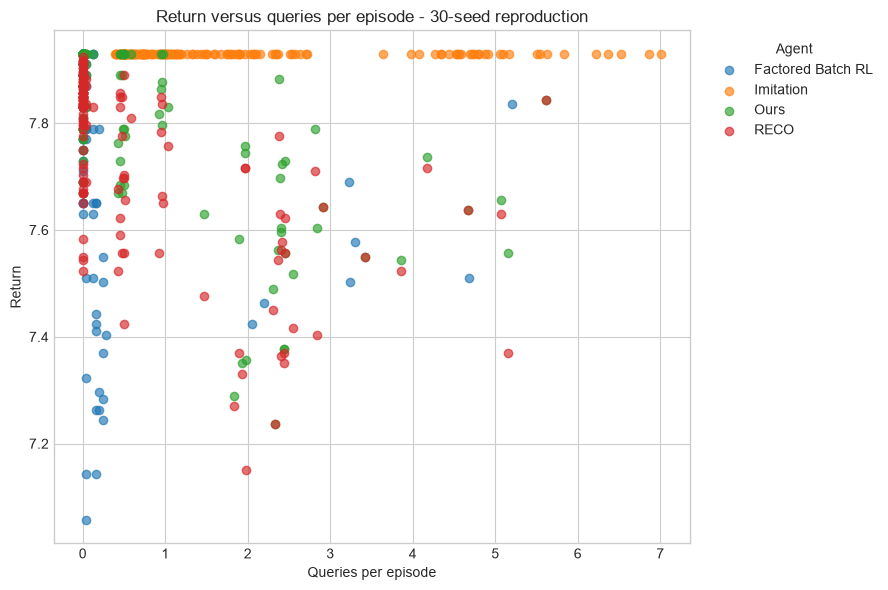

ret  queries_per_ep
agent                                                  
Factored Batch RL ret             1.000          -0.259
                  queries_per_ep -0.259           1.000
Imitation         ret               NaN             NaN
                  queries_per_ep    NaN           1.000
Ours              ret             1.000          -0.664
                  queries_per_ep -0.664           1.000
RECO              ret             1.000          -0.587
                  queries_per_ep -0.587           1.000

In [9]:
reproduction = results["reproduction_30seeds"]
reproduction_summary = (
    reproduction.groupby("agent")[["ret", "disc_ret", "queries_per_ep", "pct_delivered"]]
    .agg(["count", "mean", "std", "min", "max"])
    .sort_values(("ret", "mean"), ascending=False)
    .round(3)
)
display(reproduction_summary)

fig, ax = plt.subplots(figsize=(9, 6))
for agent, group in reproduction.groupby("agent"):
    ax.scatter(group["queries_per_ep"], group["ret"], alpha=0.65, label=agent)
ax.set_title("Return versus queries per episode - 30-seed reproduction")
ax.set_xlabel("Queries per episode")
ax.set_ylabel("Return")
ax.legend(title="Agent", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
plt.show()

reproduction.groupby("agent")[["ret", "queries_per_ep"]].corr().round(3)